# Carregamento dos Dados
1. carrega o dataset de transações de cartão de crédito
2. mostra as primeiras linhas do DataFrame

In [17]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

# Análise do Desbalanceamento
contagem de quantas vezes cada valor aparece na coluna "Class".

In [18]:
print(df["Class"].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


# Pré-processamento
criação de uma nova coluna chamada "amount_log" aplicando uma transformação logarítmica na coluna "Amount"

In [19]:
import numpy as np

df["amount_log"] = np.log1p(df["Amount"])

1. criação de uma nova coluna chamada "amount_scaled" aplicando a padronização (StandardScaler) na coluna "Amount"
2. divide os dados em conjuntos de treinamento e teste, mantendo a proporção das classes e usando 30% dos dados para teste.

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
df["amount_scaled"] = scaler.fit_transform(df[["Amount"]])

x = df.drop("Class", axis=1) # Cria a variável x contendo todas as colunas EXCETO "Class"
y = df["Class"] # Cria a variável y com apenas a coluna alvo.

X_train, X_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
    )

1. cria um modelo de regressão logística
2. ajusta o modelo aos dados de treinamento
3. faz previsões com os dados de teste

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\peixinho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


imprime um relatório de classificação para avaliar o desempenho do modelo

| Realidade | Modelo previu | Nome                     |
| --------- | ------------- | ------------------------ |
| Fraude    | Fraude        | Verdadeiro Positivo (TP) |
| Normal    | Normal        | Verdadeiro Negativo (TN) |
| Normal    | Fraude        | Falso Positivo (FP)      |
| Fraude    | Normal        | Falso Negativo (FN)      |

- precisão = Das transações que o modelo chamou de fraude, quantas realmente eram fraude?
- recall = Das fraudes reais, quantas o modelo conseguiu encontrar?
- F1-score = equilíbrio entre precisão e recall
- acurácia = quantas previsões totais o modelo acertou? (acurácia sozinha é péssima para datasets desbalanceados.)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.68      0.76       148

    accuracy                           1.00     85443
   macro avg       0.93      0.84      0.88     85443
weighted avg       1.00      1.00      1.00     85443



calcula as probabilidades de previsão para a classe 1 (fraude).

In [23]:
y_probs = model.predict_proba(X_test)[:, 1]

curva de ROC (Receiver Operating Characteristic)
- capacidade do modelo distinguir classes
- modelo bom: TPR alto, FPR baixo

AUC (Area Under the Curve)
- mede o quão bem o modelo separa fraude e normal

| AUC  | Qualidade |
| ---- | --------- |
| 0.5  | aleatório |
| 0.6  | ruim      |
| 0.7  | razoável  |
| 0.8  | bom       |
| 0.9+ | excelente |


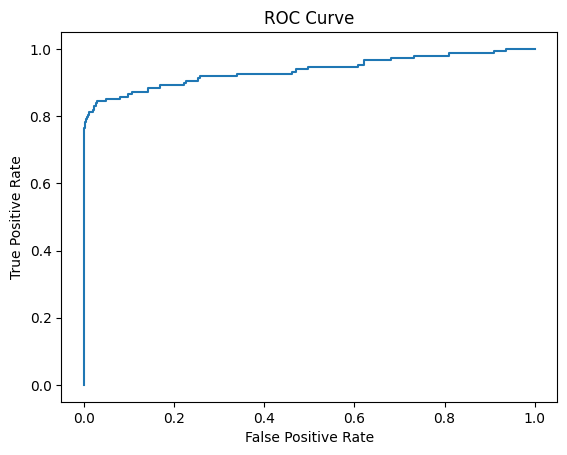

AUC: 0.9350639196556307


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_probs) # o modelo calcula pontos para construir a curva ROC.

# plota a curva ROC usando os pontos calculados e exibe o gráfico.
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show() 

print("AUC:", roc_auc_score(y_test, y_probs)) # calcula e imprime a AUC

curva de precisão-recall

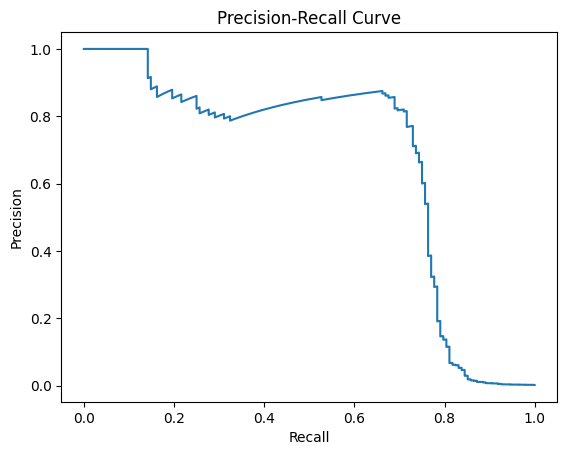

In [25]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

# plota a curva de precisão-recall usando os pontos calculados e exibe o gráfico.
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# BALANCEAMENTO DE CLASSES
**undersampling**
- reduz a classe majoritária (fraudes), mas remove muitas transações normais

**oversampling com SMOTE (Synthetic Minority Over-sampling Technique)**
- aumenta a classe minoritária criando novas fraudes artificiais

In [50]:
# undersampling
fraudes = df[df["Class"] == 1] # seleciona apenas as linhas onde  "Class" é igual a 1 (fraude).
normais = df[df["Class"] == 0].sample(n=len(fraudes), random_state=42) # pega uma amostra aleatória de transações normais.

df_under = pd.concat([fraudes, normais]) # concatena os DataFrames de fraudes e normais para criar um novo DataFrame balanceado.

X_under = df_under.drop("Class", axis=1)
y_under = df_under["Class"]

In [43]:
# oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42) # cria o algoritmo SMOTE

X_train_res, y_train_res = smote.fit_resample(X_train, y_train) # aplica o SMOTE para gerar novas amostras sintéticas da classe minoritária.

**Random Forest**
- É um conjunto de várias árvores de decisão onde cada uma vota

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50, # quantidade de árvores na floresta
    max_depth=10, # limita profundidade das árvores
    class_weight="balanced", # ajusta os pesos das classes para lidar com o desequilíbrio
    n_jobs=-1, # usa todos os núcleos do processador para treinamento
    random_state=42, # mantém a reprodutibilidade dos resultados
)

rf.fit(X_train, y_train) # treina o modelo.

y_pred_rf = rf.predict(X_test) # faz previsões.

print(classification_report(y_test, y_pred_rf)) # Imprime um relatório de classificação.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.58      0.84      0.69       148

    accuracy                           1.00     85443
   macro avg       0.79      0.92      0.84     85443
weighted avg       1.00      1.00      1.00     85443



**PipeLine**
- pipeline organiza etapas do Machine Learning em sequência.

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()), # padroniza os dados
    ("model", LogisticRegression(max_iter=1000)) # treina um modelo de regressão logística
])

pipeline.fit(X_train, y_train) # treina a regressão logística

threshold = 0.3 # define um limiar de 0.3 para classificar as previsões como fraude ou normal com base nas probabilidades previstas pelo modelo.

y_pred_custom = pipeline.predict(X_test)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.15      0.85      0.25       148

    accuracy                           0.99     85443
   macro avg       0.57      0.92      0.62     85443
weighted avg       1.00      0.99      0.99     85443



**XGBoost (Extreme Gradient Boosting)**
- cria várias árvores que aprendem sequencialmente

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier( # Cria um modelo XGBoost Classifier.
    scale_pos_weight=10, # dá mais peso para a classe positiva (fraude)
    eval_metric="logloss" # define a métrica de avaliação como logloss.
)

xgb.fit(X_train_res, y_train_res) # treinamento

y_pred_xgb = xgb.predict(X_test) # previsões

print(classification_report(y_test, y_pred_xgb))

C:\Users\peixinho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:52:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.82      0.82       148

    accuracy                           1.00     85443
   macro avg       0.90      0.91      0.91     85443
weighted avg       1.00      1.00      1.00     85443



# Importância das Variáveis

1. pega quais variáveis mais influenciaram as decisões do modelo.
2. cria um gráfico de barras com essas importâncias
3. cada barra representa uma feature/coluna

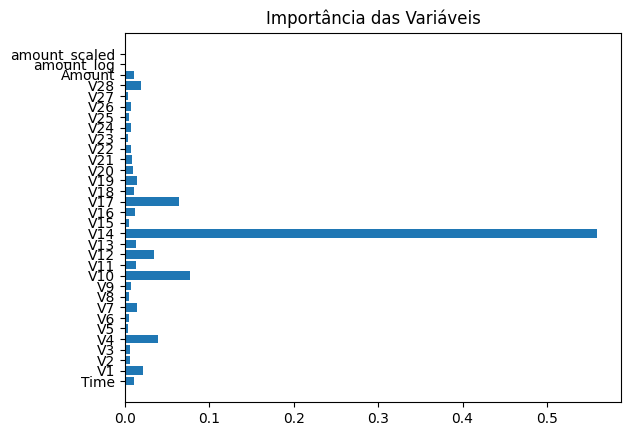

In [44]:
importancias = xgb.feature_importances_ # Pega a importância de cada coluna usada pelo modelo XGBoost.

plt.barh(X_train.columns, importancias) # Cria um gráfico de barras.
plt.title("Importância das Variáveis") # Adiciona um título ao gráfico.
plt.show() # mostra o grafico

# Ajuste de Hiperparâmetros

1. define parâmetros que deseja testar
2. GridSearch cria e testa combinações diferentes para escolher a melhor

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5], # profundidade das árvores
    "n_estimators": [50, 100], # quantidade de árvores
}

grid = GridSearchCV( # Cria um objeto GridSearchCV para realizar uma busca em grade de hiperparâmetros.
    XGBClassifier(eval_metric="logloss"), # modelo base para a busca
    param_grid=param_grid, # conjunto de hiperparâmetros a testar
    scoring="recall", # escolhe a métrica de avaliação como recall
    cv=3 # validação cruzada com 3 divisões             
)

grid.fit(X_train, y_train) # executa os testes

print("melhor modelo:", grid.best_params_) # mostra a melhor combinação encontrada

melhor modelo: {'max_depth': 3, 'n_estimators': 100}


# Explicabilidade com SHAP

**SHAP** mostra o quanto cada variável contribuiu para aumentar ou diminuir a chance de fraude.

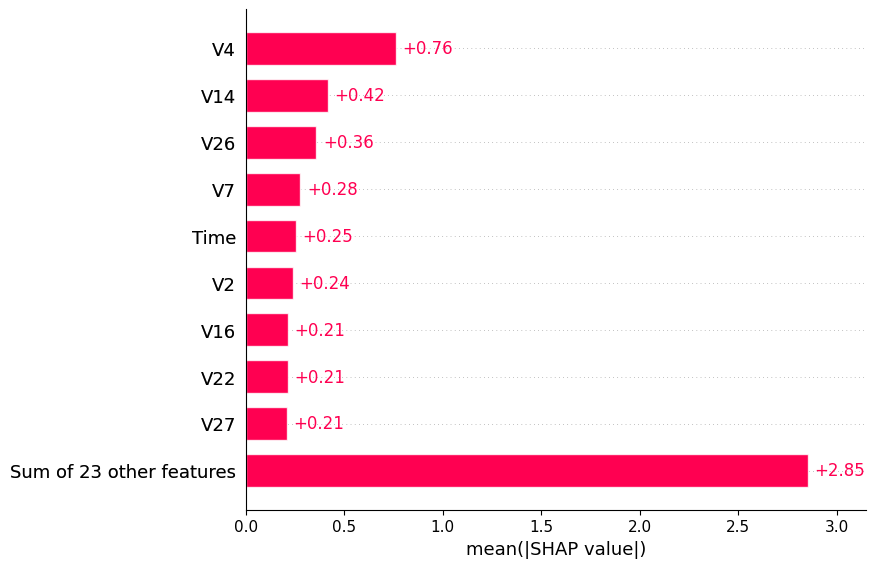

In [42]:
import shap

explainer = shap.Explainer(xgb, X_train) # mostra o quanto cada variável contribui para a previsão do modelo.
shap_values = explainer(X_test[:100]) # calcula os valores SHAP para as primeiras 100 amostras do conjunto de teste.

shap.plots.bar(shap_values) # gráfico com as variáveis mais importantes para as previsões do modelo.

## Conclusão

O projeto comparou modelos de Machine Learning para detecção de fraudes em transações financeiras.  
Como o dataset é altamente desbalanceado, foram avaliadas estratégias como ajuste de pesos e SMOTE.  
As métricas mais importantes para este problema foram recall, precision, F1-score e AUC.